**fashion_mnist 데이터셋**
- torchvision에 내장된 예제 데이터
- 운동화, 셔츠, 샌들 등 작은 이미지의 모음
- 열 가지로 분류될 수 있는 28x28 픽셀 이미지 7만 개
<br>

train_images: 0~255 값을 갖는 28x28 크기의 넘파이 배열

train_labels: 0~9 정수 값을 갖는 배열

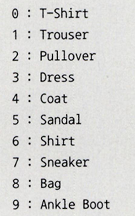

In [2]:
# 라이브러리 호출
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision # 이미지 관련 라이브러리
import torchvision.transforms as transforms # 데이터 전처리 라이브러리
from torch.utils.data import Dataset, DataLoader

In [3]:
# CPU GPU 장치 설정
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## fashion_mnist 데이터셋 준비

In [4]:
train_dataset = torchvision.datasets.FashionMNIST(
    "/content/drive/MyDrive/Euron Homework/dataset",
    download=True, transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST(
    "/content/drive/MyDrive/Euron Homework/dataset",
    download=True, train=False, transform=transforms.Compose([transforms.ToTensor()]))

**torchvision.datasets**: torch.utils.data.Dataset 하위 클래스로, CIFAR, COCO, MNIST, ImageNet 등 다양한 데이터셋을 포함함
  - 첫 번째 파라미터 `"../~"`: FashionMNIST 내려받을 위치 지정
  - `download`: 지정한 파일 위치에 해당 데이터셋이 있는지 확인 후 내려받음
  - `transform`: 이미지 -> 텐서(0~1) 변경

In [5]:
# fashion_mnist 데이터를 데이터로더에 전달
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100)

**torch.utils.data.DataLoader()**: 원하는 크기의 배치 단위로 데이터를 불러오거나 shuffle 가능
- 첫 번째 파라미터: 데이터셋 지정
- `batch_size`: 데이터를 지정 크기의 배치로 묶음

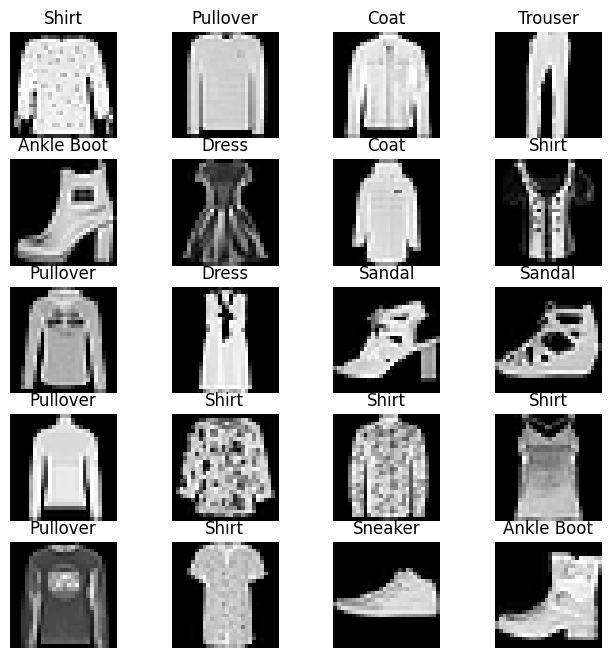

In [6]:
# 분류에 사용될 클래스 정의
labels_map = {0 : 'T-Shirt', 1 : 'Trouser', 2 : 'Pullover', 3 : 'Dress', 4 : 'Coat', 5 : 'Sandal', 6 : 'Shirt',
              7 : 'Sneaker', 8 : 'Bag', 9 : 'Ankle Boot'} # 10개 클래스

fig = plt.figure(figsize=(8,8)) # 출력할 이미지의 가로세로 길이 - inch
columns = 4
rows = 5
for i in range(1, columns*rows+1): # C x R 개 이미지 출력
  img_xy = np.random.randint(len(train_dataset)) # 무작위 데이터 생성
  img = train_dataset[img_xy][0][0,:,:] # train_dataset 으로 3차원 배열 생성
  fig.add_subplot(rows,columns,i)
  plt.title(labels_map[train_dataset[img_xy][1]])
  plt.axis('off')
  plt.imshow(img,cmap='gray')
plt.show() # 20개 이미지 데이터 시각적으로 표현

- `np.random.randint()`: 이산형(정수) 분포 데이터에서 무작위 표본 추출

In [ ]:
# random 연습
import numpy as np
print(np.random.randint(10)) # 0~10
print(np.random.randint(1,10)) # 1~9
print(np.random.rand(8)) # 0~1 사이의 정규표준분포 난수를 1x8 행렬로 출력
print(np.random.rand(4,2)) # 4x2 행렬로 출력
print(np.random.randn(8)) # 평균 0, 표준편차 1인 가우시안 정규분포 난수를 1x8 행렬로 출력
print(np.random.randn(4,2)) # 4x2 행렬로 출력

5
6
[0.0597168  0.48237409 0.89008351 0.23521984 0.97097257 0.51424635
 0.44601802 0.95514722]
[[0.01438313 0.36339715]
 [0.25406386 0.27932922]
 [0.01467906 0.62476108]
 [0.83439706 0.51062455]]
[-0.10614376  0.31235743  1.52101789  0.14908187  0.1160938  -0.30180777
  0.7209154  -0.36892106]
[[-1.93196749 -0.53518276]
 [-0.61902537  0.0832951 ]
 [ 2.13719377  0.48206138]
 [ 2.43165107 -1.1797152 ]]


## DNN

### 모델 생성

In [ ]:
# 심층 신경망(DNN) 모델 생성
class FashionDNN(nn.Module): # class 형태의 모델은 항상 torch.nn.Module 상속받음
  def __init__(self):        # 객체 속성 값 초기화, 객체 생성 시 자동 호출
    super(FashionDNN, self).__init__() # FashionDNN이라는 부모 클래스를 상속받겠다
    self.fc1 = nn.Linear(in_features=784, out_features=256) # 선형 회귀 모델
    self.drop = nn.Dropout(0.25) # 0.25 확률로 텐서 값이 0이 됨, 나머지는 (1/(1-p)) 곱해져 커짐
    self.fc2 = nn.Linear(in_features=256, out_features=128)
    self.fc3 = nn.Linear(in_features=128, out_features=10)

  # forward: 모델 학습 데이터 입력받아서 순전파 학습 진행하는 함수
  ## 객체를 데이터와 함께 호출하면 자동 실행
  def forward(self, input_data):
    out = input_data.view(-1, 784) # input_data -> ((자동계산), 784) 크기로 변경
    out = F.relu(self.fc1(out)) # 활성화 함수를 forward 함수에서 지정한 경우
    out = self.drop(out)
    out = F.relu(self.fc2(out))
    out = self.fc3(out)
    return out

- nn: 딥러닝 모델(네트워크) 구성에 필요한 모듈이 모여 있는 패키지
- nn.Linear: 단순 선형 회귀 모델 생성
  - `in_features`: 입력 크기 (input size)
  - `out_features`: 출력 크기 (output size)
- 활성화 함수 지정
  - nn.ReLU(): \_\_init__() 함수에서 정의, 파라미터(input_channel, output_channel 등)를 사용
  - nn.functional.relu(): forward() 함수에서 정의, 입력(input)과 가중치 자체를 매번 새로 정의해서 직접 넣어줌
  <br>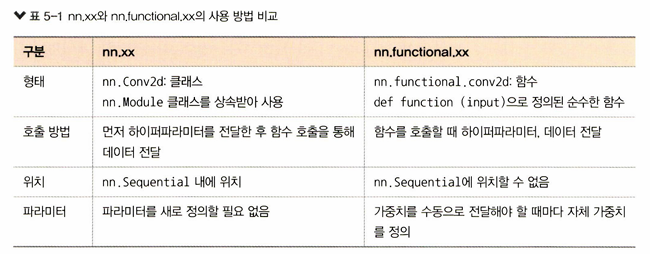

### 모델 학습

In [ ]:
# 손실 함수, 학습률, 옵티마이저 정의
learning_rate = 0.001
model = FashionDNN()
model.to(device)

criterion = nn.CrossEntropyLoss() # 분류 문제에서 사용하는 손실 함수
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) # Adam 경사하강법 사용
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
# 모델 학습
num_epochs = 5
count=0

loss_list=[]
iteration_list=[]
accuracy_list=[]

predictions_list=[]
labels_list=[]

for epoch in range(num_epochs): # 전체 데이터셋을 epoch 만큼 반복해서 하습
  for images, labels in train_loader: # 레코드(행)를 하나씩? 배치 하나씩? 가져옴
    images, labels = images.to(device), labels.to(device) # 모델과 데이터는 동일한 장치에 존재해야 함

    # Autograd 사용하기 위해 Variable 생성
    train = Variable(images.view(100,1,28,28)) # 이미지 크기 28x28
    labels = Variable(labels)

    outputs = model(train) # 학습 데이터 모델 적용
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count+=1 # 배치 단위 학습 횟수 (iteration) == 가중치 업데이트 횟수

    if not (count % 50): # if count % 50 == 0: 과 동일
      total=0
      correct=0
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100,1,28,28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device) # 계산값 중 제일 높은 확률을 예측값으로 선정
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()
        total+=len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count % 500): # if count % 500 == 0: 과 동일
      print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.5514140129089355, Accuracy: 82.68999481201172%
Iteration: 1000, Loss: 0.4901455044746399, Accuracy: 84.6199951171875%
Iteration: 1500, Loss: 0.36119014024734497, Accuracy: 84.25999450683594%
Iteration: 2000, Loss: 0.3665814995765686, Accuracy: 85.86000061035156%
Iteration: 2500, Loss: 0.2631737291812897, Accuracy: 86.18000030517578%
Iteration: 3000, Loss: 0.27567631006240845, Accuracy: 86.25%


- Autograd: 자동 미분 수행하는 파이토치의 핵심 패키지로 tape를 사용함. tape는 순전파 단계에서 수행하는 모든 연산을 저장한 뒤, 역전파 단계에서 저장된 값들을 꺼내서 사용함.

## CNN

## 모델 생성

In [7]:
class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN, self).__init__()
    self.layer1 = nn.Sequential( # nn.Sequential: 모델 정의 + 계층 형태의 하나의 컨테이너로 묶음
        nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1), # 합성곱 연산
        ## fashion_mnist 입력 데이터 크기 28*28=784, default stride (1,1)
        ## (784 - 3 + (2*1))/1 + 1 = 784 => [32, 784, 784]
        nn.BatchNorm2d(32), # 정규화
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2) # 이미지 크기 축소 - 최대 풀링
        ## 784/2 = 392 => [32, 392, 392]
    )
    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    # 클래스 분류를 위해서는 이미지 형태의 데이터를 배열 형태로 변환해 작업해야 함
    self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)
    self.drop=nn.Dropout2d(0.25)
    self.fc2 = nn.Linear(in_features=600, out_features=120)
    self.fc3 = nn.Linear(in_features=120, out_features=10)

  def forward(self, x):
    # 합성곱층
    out = self.layer1(x)
    out = self.layer2(out)
    out = out.view(out.size(0), -1) # 데이터 형태 1차원으로 변경 (100,?) 텐서
    # 완전연결층
    out = self.fc1(out)
    out = self.drop(out)
    out = self.fc2(out)
    out = self.fc3(out)
    return out

- nn.Conv2d: 합성곱 연사을 통해 이미지의 특징 추출
  - in_channels: 입력 채널 수 (흑백-1, RGB-3)
  - out_channels: 출력 채널 수
  - kernel_size: 커널 크기
    - 커널: 이미지 특징을 찾아내기 위한 **공용 파라미터**. CNN에서 학습 대상은 필터 파라미터가 됨.
  - padding: 패딩 크기. 출력 크기 조정을 위해 입력 데이터 주위에 0을 채움
- BatchNorm2d: 학습 과정에서 각 배치 단위별로 데이터가 다양한 분포를 가지더라도 평균과 분산을 이용해 정규화함
  <br>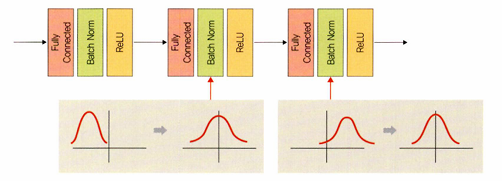

In [8]:
# 합성곱 네트워크 파라미터 정의
learning_rate = 0.001
model = FashionCNN()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


### 모델 학습

In [9]:
# 모델 학습
num_epochs = 5
count=0

loss_list=[]
iteration_list=[]
accuracy_list=[]

predictions_list=[]
labels_list=[]

for epoch in range(num_epochs): # 전체 데이터셋을 epoch 만큼 반복해서 하습
  for images, labels in train_loader: # 레코드(행)를 하나씩? 배치 하나씩? 가져옴
    images, labels = images.to(device), labels.to(device) # 모델과 데이터는 동일한 장치에 존재해야 함

    # Autograd 사용하기 위해 Variable 생성
    train = Variable(images.view(100,1,28,28)) # 이미지 크기 28x28
    labels = Variable(labels)

    outputs = model(train) # 학습 데이터 모델 적용
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count+=1 # 배치 단위 학습 횟수 (iteration) == 가중치 업데이트 횟수

    if not (count % 50): # if count % 50 == 0: 과 동일
      total=0
      correct=0
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100,1,28,28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device) # 계산값 중 제일 높은 확률을 예측값으로 선정
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()
        total+=len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count % 500): # if count % 500 == 0: 과 동일
      print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:1535: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


Iteration: 500, Loss: 0.44179022312164307, Accuracy: 87.47000122070312%
Iteration: 1000, Loss: 0.3393380343914032, Accuracy: 88.79999542236328%
Iteration: 1500, Loss: 0.29930609464645386, Accuracy: 88.5199966430664%
Iteration: 2000, Loss: 0.2232835739850998, Accuracy: 89.93999481201172%
Iteration: 2500, Loss: 0.1460144817829132, Accuracy: 89.91999816894531%
Iteration: 3000, Loss: 0.20952457189559937, Accuracy: 89.75%


심층 신경망 마지막 Accuracy 86.75%

합성곱 신경망 마지막 Accuracy 89.75%

-> CNN 정확도가 약간 더 높음

<br> 이미지 데이터가 많아지면 단순 DNN으로는 정확한 특성 추출 및 분류 불가능 -> CNN을 사용할 것